# Visualization with Seaborn

Matplotlib has been at the core of scientific visualization in Python for decades, but even avid users will admit it often leaves much to be desired.
There are several complaints about Matplotlib that often come up:

- A common early complaint, which is now outdated: prior to version 2.0, Matplotlib's color and style defaults were at times poor and looked dated.
- Matplotlib's API is relatively low-level. Doing sophisticated statistical visualization is possible, but often requires a *lot* of boilerplate code.
- Matplotlib predated Pandas by more than a decade, and thus is not designed for use with Pandas `DataFrame` objects. In order to visualize data from a `DataFrame`, you must extract each `Series` and often concatenate them together into the right format. It would be nicer to have a plotting library that can intelligently use the `DataFrame` labels in a plot.

An answer to these problems is [Seaborn](http://seaborn.pydata.org/). Seaborn provides an API on top of Matplotlib that offers sane choices for plot style and color defaults, defines simple high-level functions for common statistical plot types, and integrates with the functionality provided by Pandas.

To be fair, the Matplotlib team has adapted to the changing landscape: it added the `plt.style` tools discussed in [Customizing Matplotlib: Configurations and Style Sheets](04.11-Settings-and-Stylesheets.ipynb), and Matplotlib is starting to handle Pandas data more seamlessly.
But for all the reasons just discussed, Seaborn remains a useful add-on.

By convention, Seaborn is often imported as `sns`:

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set()  # seaborn's method to set its chart style
# seaborn 的一键美化命令，作用相当于一次性帮你设好一堆 plt.rcParams

## Exploring Seaborn Plots

The main idea of Seaborn is that it provides high-level commands to create a variety of plot types useful for statistical data exploration, and even some statistical model fitting.

Let's take a look at a few of the datasets and plot types available in Seaborn. Note that all of the following *could* be done using raw Matplotlib commands (this is, in fact, what Seaborn does under the hood), but the Seaborn API is much more convenient.

### Histograms, KDE, and Densities

Often in statistical data visualization, all you want is to plot histograms and joint distributions of variables.
We have seen that this is relatively straightforward in Matplotlib (see the following figure):

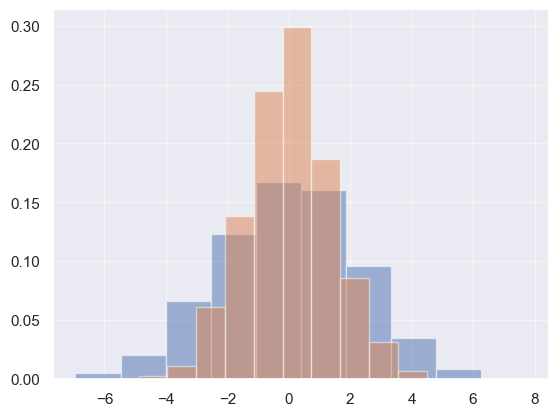

In [9]:
data = np.random.multivariate_normal([0, 0], [[5, 2], [2, 2]], size=2000)
data = pd.DataFrame(data, columns=['x', 'y'])

for col in 'xy':
    plt.hist(data[col], density=True, alpha=0.5)

Rather than just providing a histogram as a visual output, we can get a smooth estimate of the distribution using kernel density estimation (introduced in [Density and Contour Plots](04.04-Density-and-Contour-Plots.ipynb)), which Seaborn does with ``sns.kdeplot`` (see the following figure):

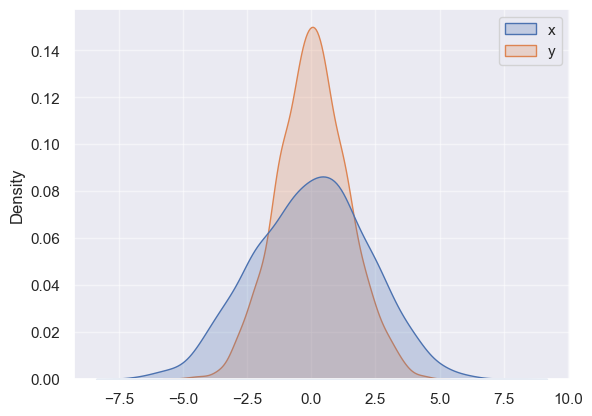

In [10]:
sns.kdeplot(data=data, fill=True);
# 画核密度估计曲线——可以理解为"平滑版的直方图"

If we pass `x` and `y` columns to `kdeplot`, we instead get a two-dimensional visualization of the joint density (see the following figure):

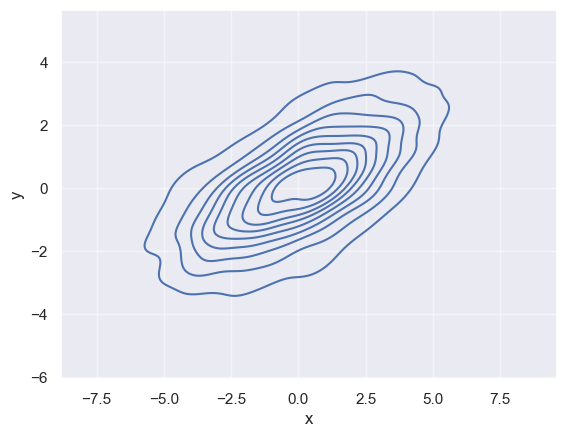

In [11]:
sns.kdeplot(data=data, x='x', y='y');
# seaborn 版的二维密度等高线图

| matplotlib 原生 | seaborn |
|------|---------|
| `plt.hist(x)` → 一维直方图 | `sns.kdeplot(x='x')` → 平滑密度曲线 |
| `plt.hist2d(x, y)` → 二维分箱 | `sns.kdeplot(x='x', y='y')` → 二维密度等高线 |
| `plt.contour(X, Y, Z)` → 手动插值 | 自动从原始点算密度 |

We can see the joint distribution and the marginal distributions together using `sns.jointplot`, which we'll explore further later in this chapter.

### Pair Plots

When you generalize joint plots to datasets of larger dimensions, you end up with *pair plots*. These are very useful for exploring correlations between multidimensional data, when you'd like to plot all pairs of values against each other.

We'll demo this with the well-known Iris dataset, which lists measurements of petals and sepals of three Iris species:

In [18]:
import pandas as pd
iris = pd.read_csv('../notebooks/data/iris.csv')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.173850,3.358521,1.759075,0.428454,setosa
1,4.918046,3.329759,2.131685,0.315115,setosa
2,4.835684,3.562768,1.314633,0.130141,setosa
3,5.084687,2.826016,0.810033,0.115657,setosa
4,4.645509,3.494274,1.136790,-0.011846,setosa


Visualizing the multidimensional relationships among the samples is as easy as calling ``sns.pairplot`` (see the following figure):

`pairplot` 画的是 **数值列 × 数值列** 的 N×N 矩阵图，`hue` 列不参与画图，只用来分颜色。

以 iris 为例（4 个数值列 + 1 个 species）：

|             | sepal_length | sepal_width | petal_length | petal_width |
|-------------|-------------|-------------|-------------|-------------|
| sepal_length | 直方图     | 散点        | 散点        | 散点        |
| sepal_width  | 散点       | 直方图      | 散点        | 散点        |
| petal_length | 散点       | 散点        | 直方图      | 散点        |
| petal_width  | 散点       | 散点        | 散点        | 直方图      |

- **对角线**：单特征的分布图（直方图或 KDE）
- **非对角线**：两个特征间的散点图
- **`hue='species'`**：上面所有图按品种着色，species 列本身不画进去a v

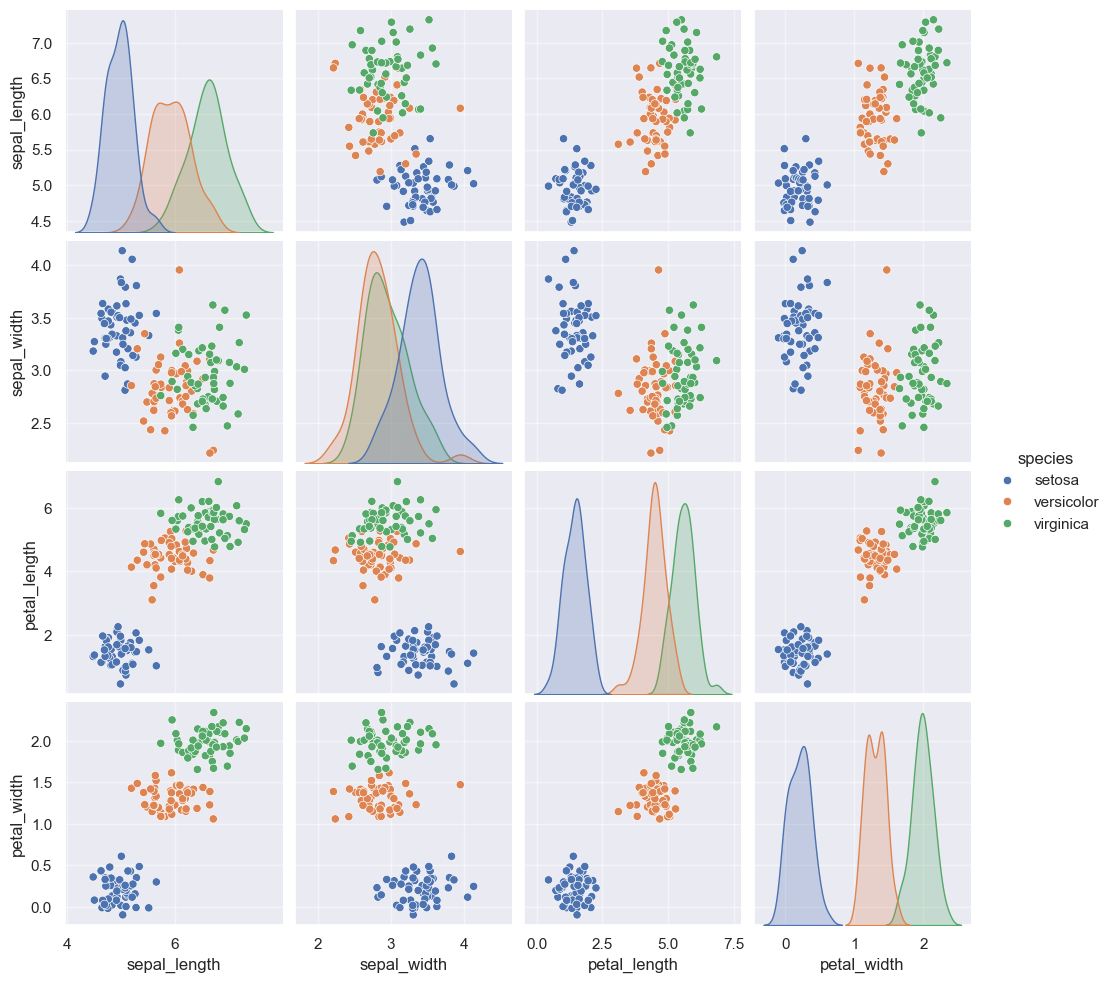

In [19]:
sns.pairplot(iris, hue='species', height=2.5);
# seaborn 的两两散点图矩阵——当你有一个数据集有多列数值特征时，自动画每一对特征之间的散点图
# hue 决定按 species 列的值分颜色，不同品种的点显示不同颜色，图例自动生成
# height 决定每个子图的边长（英寸），默认 2.5。整个图是 N×N 网格，设大了每个子图都变大，设小了就变小

### Faceted Histograms

Sometimes the best way to view data is via histograms of subsets, as shown in the following figure. Seaborn's `FacetGrid` makes this simple.
We'll take a look at some data that shows the amount that restaurant staff receive in tips based on various indicator data:[^1]

[^1]: The restaurant staff data used in this section divides employees into two sexes: female and male. Biological sex
isn’t binary, but the following discussion and visualizations are limited by this data.

In [21]:
tips = pd.read_csv('../notebooks/data/tips.csv')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,27.63,2.68,Male,Yes,Sat,Dinner,3
1,33.69,3.91,Male,No,Sat,Dinner,2
2,29.86,3.87,Male,No,Fri,Dinner,3
3,16.81,3.08,Female,No,Thur,Lunch,2
4,23.92,2.89,Female,No,Sun,Dinner,4


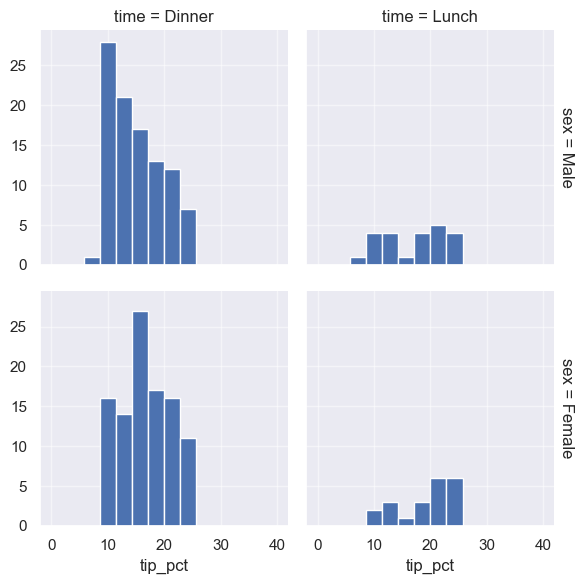

In [22]:
tips['tip_pct'] = 100 * tips['tip'] / tips['total_bill']

grid = sns.FacetGrid(tips, row="sex", col="time", margin_titles=True) # 按指定列分面，把数据拆成多个子图
# margin_titles=True 控制行列标签显示在边缘，不在每个子图上方
grid.map(plt.hist, "tip_pct", bins=np.linspace(0, 40, 15));
# grid.map(画图函数, "列名") 就是在每个子图里画那一列的分布
# 此处画的是tip_pct从0%到40%平分为15分，每个区间的样本个数

The faceted chart gives us some quick insights into the dataset: for example, we see that it contains far more data on male servers during the dinner hour than other categories, and typical tip amounts appear to range from approximately 10% to 20%, with some outliers on either end.

### Categorical Plots

Categorical plots can be useful for this kind of visualization as well. These allow you to view the distribution of a parameter within bins defined by any other parameter, as shown in the following figure:

| `kind` 值 | 画的图 | 说明 |
|-----------|--------|------|
| `'box'` | 箱线图 | 显示中位数、四分位距、异常值 |
| `'violin'` | 小提琴图 | 箱线图 + KDE，展示分布形状 |
| `'boxen'` | 增强箱线图 | 大数据集时更细腻的箱线图 |
| `'bar'` | 柱状图 | 显示均值，误差条 |
| `'point'` | 点图 | 显示均值连线，适合对比趋势 |
| `'strip'` | 散点条 | 每个数据点一个点，会重叠 |
| `'swarm'` | 蜂群散点图 | 类似 strip 但点不重叠 |a v

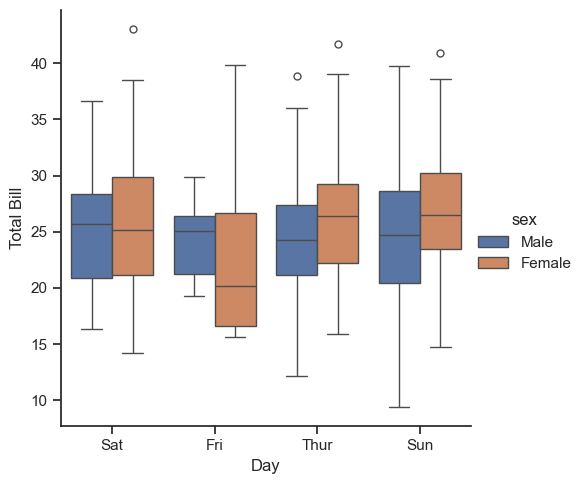

In [23]:
with sns.axes_style(style='ticks'):
    g = sns.catplot(x="day", y="total_bill", hue="sex", data=tips, kind="box")
    g.set_axis_labels("Day", "Total Bill");

### Joint Distributions

Similar to the pair plot we saw earlier, we can use `sns.jointplot` to show the joint distribution between different datasets, along with the associated marginal distributions (see the following figure):

| `kind` | 中间主图 | 类似哪个 matplotlib 函数 |
|--------|---------|------------------------|
| `'scatter'` | 散点图（默认） | `plt.scatter` |
| `'kde'` | 二维密度等高线 | `plt.contour` + `plt.contourf` |
| `'hex'` | 六边形分箱 | `plt.hexbin` |
| `'reg'` | 散点 + 回归线 | `plt.scatter` + 拟合线 |
| `'hist'` | 二维直方图 | `plt.hist2d` |a v

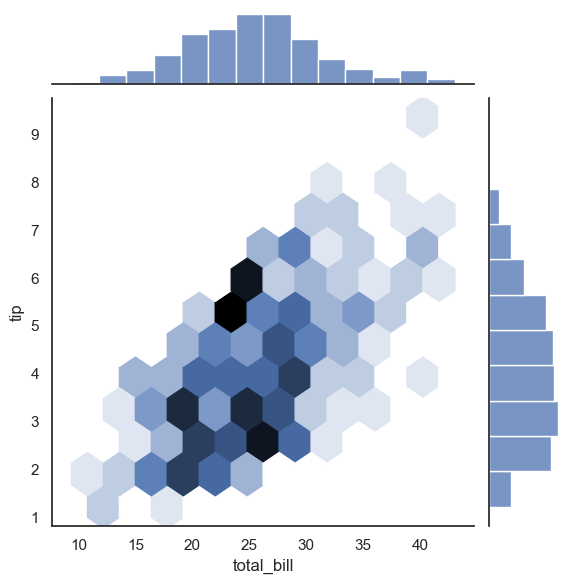

In [24]:
with sns.axes_style('white'):
    sns.jointplot(x="total_bill", y="tip", data=tips, kind='hex') # 画的是双变量联合图——中间是散点图，边缘是单变量分布

The joint plot can even do some automatic kernel density estimation and regression, as shown in the following figure:

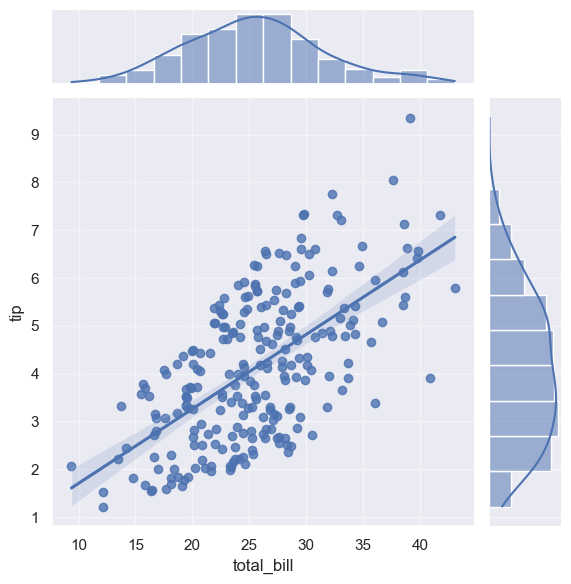

In [25]:
sns.jointplot(x="total_bill", y="tip", data=tips, kind='reg');

### Bar Plots

Time series can be plotted using `sns.factorplot`. In the following example, we'll use the Planets dataset that we first saw in [Aggregation and Grouping](03.08-Aggregation-and-Grouping.ipynb); see the following figure for the result:

In [26]:
planets = pd.read_csv('../notebooks/data/planets.csv')
planets.head()

,method,orbital_period,mass,distance,year
0,Radial Velocity,22.6843,351.6422,22.22,1992
1,Transit,1236.2952,0.1650,207.77,1992
2,Radial Velocity,1259.1416,234.1264,31.16,1992
3,Radial Velocity,46.4020,14.7025,4.41,1992
4,Imaging,0.4577,281.5574,301.93,1992


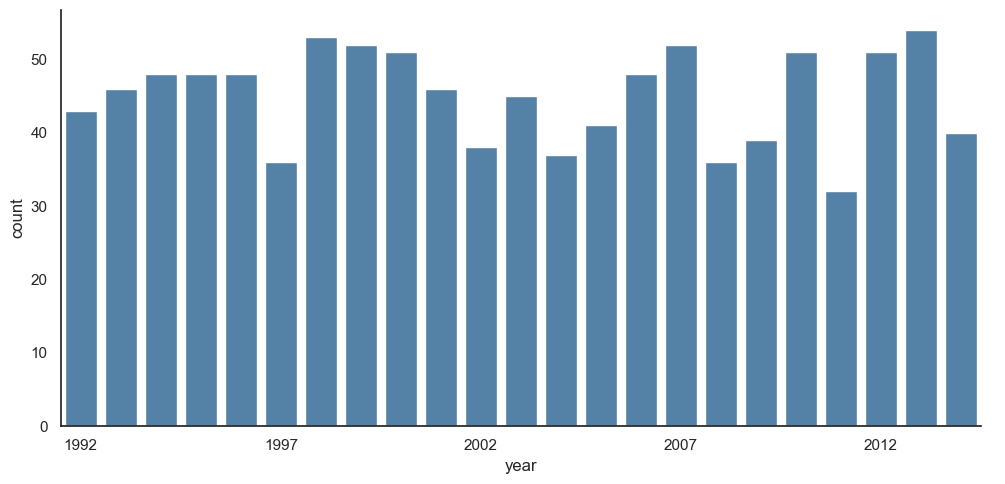

In [30]:
with sns.axes_style('white'):
    g = sns.catplot(x="year", data=planets, aspect=2,
                    kind="count", color='steelblue') # aspect 控制子图的宽高比；=1 为正方形，=2 宽度是高度的两倍
    g.set_xticklabels(step=5)
    # 每隔 5 个显示一个 x 轴标签

We can learn more by looking at the *method* of discovery of each of these planets (see the following figure):

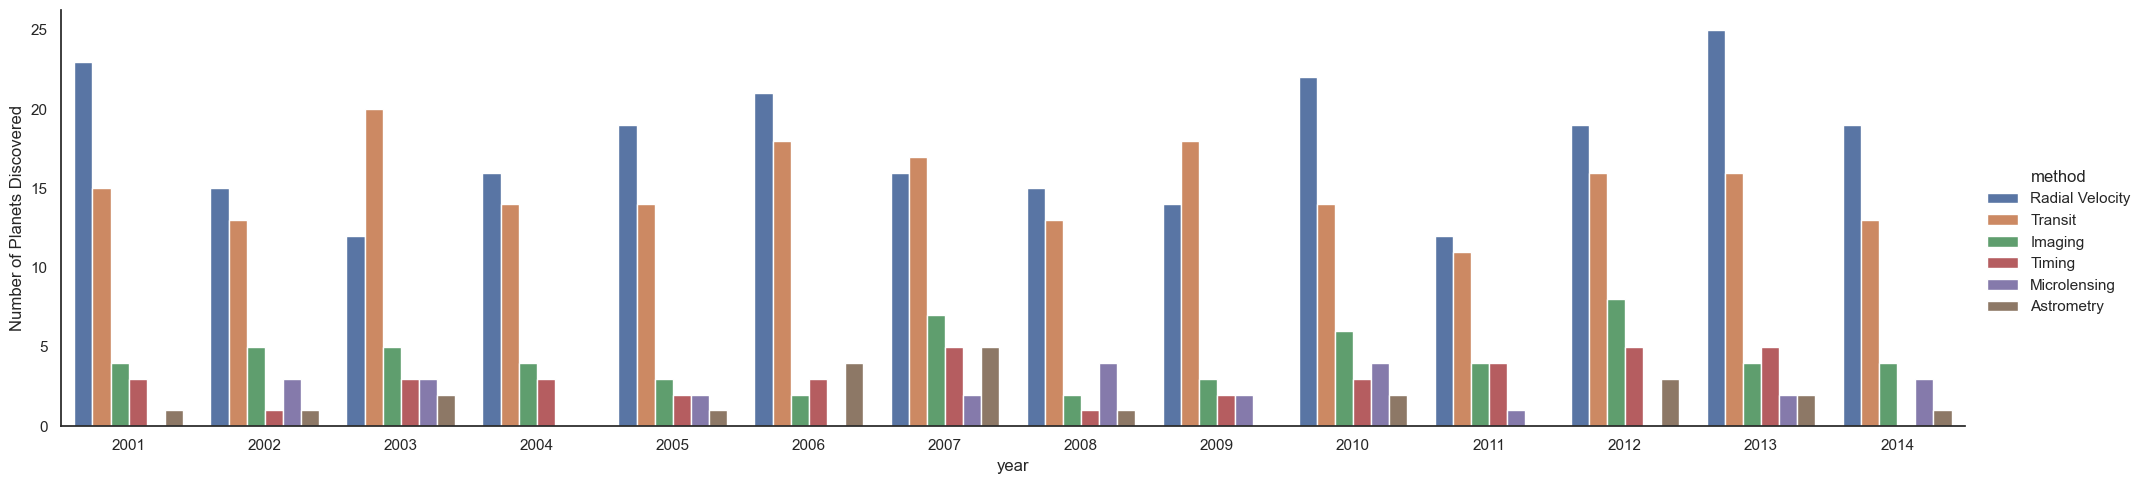

In [31]:
with sns.axes_style('white'):
    g = sns.catplot(x="year", data=planets, aspect=4.0, kind='count',
                    hue='method', order=range(2001, 2015)) # order 控制 x 轴显示哪些类别以及按什么顺序显示
    g.set_ylabels('Number of Planets Discovered')

For more information on plotting with Seaborn, see the [Seaborn documentation](http://seaborn.pydata.org/), and particularly the [example gallery](https://seaborn.pydata.org/examples/index.html).

## Example: Exploring Marathon Finishing Times

Here we'll look at using Seaborn to help visualize and understand finishing results from a marathon.
I've scraped the data from sources on the web, aggregated it and removed any identifying information, and put it on GitHub, where it can be downloaded
(if you are interested in using Python for web scraping, I would recommend [*Web Scraping with Python*](http://shop.oreilly.com/product/0636920034391.do) by Ryan Mitchell, also from O'Reilly).
We will start by downloading the data and loading it into Pandas:[^2]

[^2]: The marathon data used in this section divides runners into two genders: men and women. While gender is a
spectrum, the following discussion and visualizations use this binary because they depend on the data.

In [ ]:
# url = ('https://raw.githubusercontent.com/jakevdp/'
#        'marathon-data/master/marathon-data.csv')
# !cd data && curl -O {url}

In [33]:
data = pd.read_csv('../notebooks/data/marathon-data.csv')
data.head()

,gender,split,final
0,M,01:22:41,02:47:51
1,F,01:39:12,03:39:28
2,F,01:38:26,03:40:43
3,M,02:26:50,05:04:10
4,M,01:51:09,03:52:36


Notice that Pandas loaded the time columns as Python strings (type `object`); we can see this by looking at the `dtypes` attribute of the `DataFrame`:

In [34]:
data.dtypes

gender    str
split     str
final     str
dtype: object

Let's fix this by providing a converter for the times:

In [37]:
import datetime

def convert_time(s):
    h, m, s = map(int, s.split(':'))
    return datetime.timedelta(hours=h, minutes=m, seconds=s)

data = pd.read_csv('data/marathon-data.csv',
                   converters={'split':convert_time, 'final':convert_time})
data.head()

,gender,split,final
0,M,0 days 01:22:41,0 days 02:47:51
1,F,0 days 01:39:12,0 days 03:39:28
2,F,0 days 01:38:26,0 days 03:40:43
3,M,0 days 02:26:50,0 days 05:04:10
4,M,0 days 01:51:09,0 days 03:52:36


In [38]:
data.dtypes

gender                str
split     timedelta64[us]
final     timedelta64[us]
dtype: object

That will make it easier to manipulate the temporal data. For the purpose of our Seaborn plotting utilities, let's next add columns that give the times in seconds:

In [40]:
data['split_sec'] = data['split'].dt.total_seconds()
data['final_sec'] = data['final'].dt.total_seconds()

To get an idea of what the data looks like, we can plot a `jointplot` over the data; the following figure shows the result:

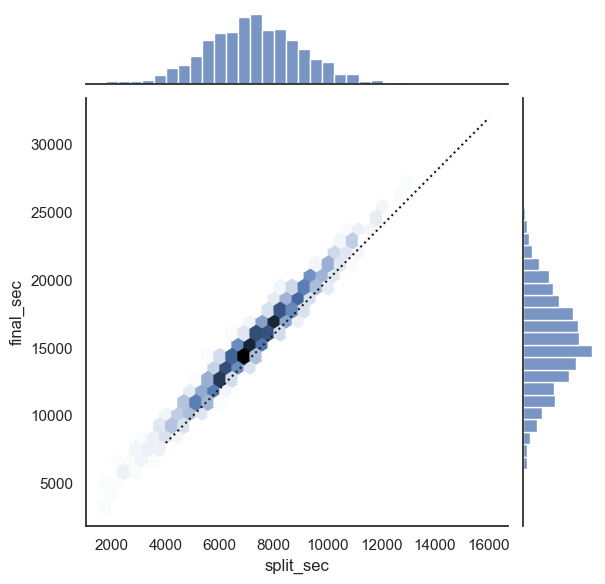

In [41]:
with sns.axes_style('white'):
    g = sns.jointplot(x='split_sec', y='final_sec', data=data, kind='hex')
    g.ax_joint.plot(np.linspace(4000, 16000),
                    np.linspace(8000, 32000), ':k') # 在 jointplot 中间的主图（ax_joint）上加一条对角线参考线
    # ax_joint 是 jointplot 返回的 JointGrid 对象特有的属性

The dotted line shows where someone's time would lie if they ran the marathon at a perfectly steady pace. The fact that the distribution lies above this indicates (as you might expect) that most people slow down over the course of the marathon.
If you have run competitively, you'll know that those who do the opposite—run faster during the second half of the race—are said to have "negative-split" the race.

Let's create another column in the data, the split fraction, which measures the degree to which each runner negative-splits or positive-splits the race:

In [42]:
data['split_frac'] = 1 - 2 * data['split_sec'] / data['final_sec']
data.head()

,gender,split,final,split_sec,final_sec,split_frac
0,M,0 days 01:22:41,0 days 02:47:51,4961.0,10071.0,0.014795
1,F,0 days 01:39:12,0 days 03:39:28,5952.0,13168.0,0.095990
2,F,0 days 01:38:26,0 days 03:40:43,5906.0,13243.0,0.108057
3,M,0 days 02:26:50,0 days 05:04:10,8810.0,18250.0,0.034521
4,M,0 days 01:51:09,0 days 03:52:36,6669.0,13956.0,0.044282


Where this split difference is less than zero, the person negative-split the race by that fraction.
Let's do a distribution plot of this split fraction (see the following figure):

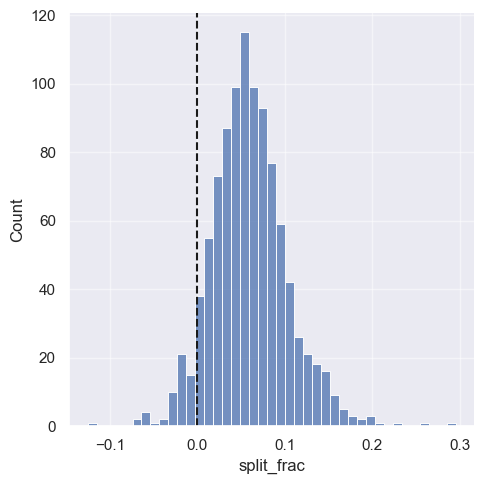

In [43]:
sns.displot(data['split_frac'], kde=False)
plt.axvline(0, color="k", linestyle="--"); # 在 0 处画条虚线

In [44]:
sum(data.split_frac < 0)

68

Out of nearly 40,000 participants, there were only 250 people who negative-split their marathon.

Let's see whether there is any correlation between this split fraction and other variables. We'll do this using a `PairGrid`, which draws plots of all these correlations (see the following figure):

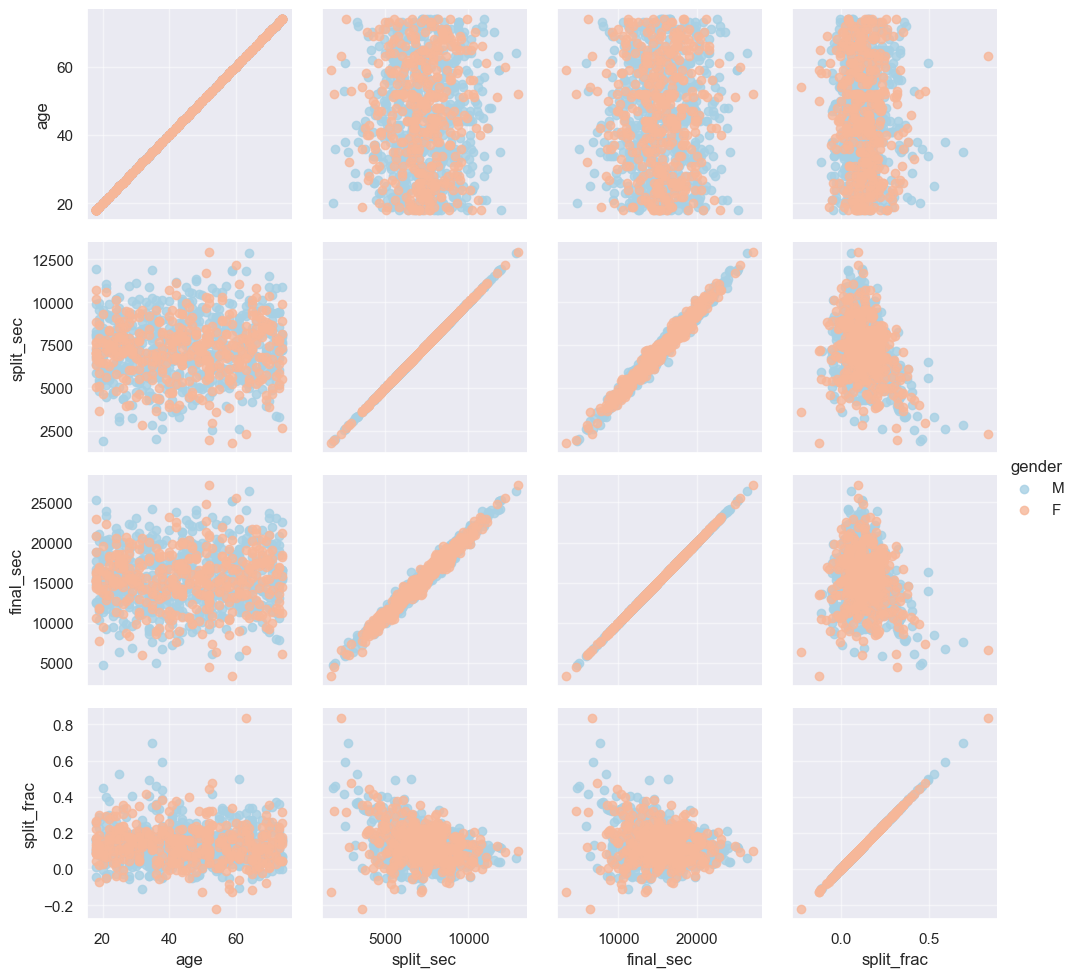

In [48]:
data['split_frac'] = (data['final_sec'] - 2 * data['split_sec']) / data['split_sec']
data['age'] = np.random.randint(18, 75, len(data))
g = sns.PairGrid(data, vars=['age', 'split_sec', 'final_sec', 'split_frac'],
                 hue='gender', palette='RdBu_r') # palette 是 seaborn 的调色板参
# pairplot 的手动版，可以通过 var 决定画哪些列
g.map(plt.scatter, alpha=0.8)
g.add_legend();

| 对象 | 框架 | 填内容 | 一句话 |
|------|------|--------|--------|
| `PairGrid` | 手动创建 | `.map()` / `.map_diag()` / `.map_offdiag()` | "给你个空网格，你自己画" |
| `FacetGrid` | 手动创建 | `.map()` | "按分类列分面，每格画同一列" |
| `pairplot` | 自动创建 | 自动画好 | "PairGrid 的一键版，不用管细节" |b v

It looks like the split fraction does not correlate particularly with age, but does correlate with the final time: faster runners tend to have closer to even splits on their marathon time. Let's zoom in on the histogram of split fractions separated by gender, shown in the following figure:

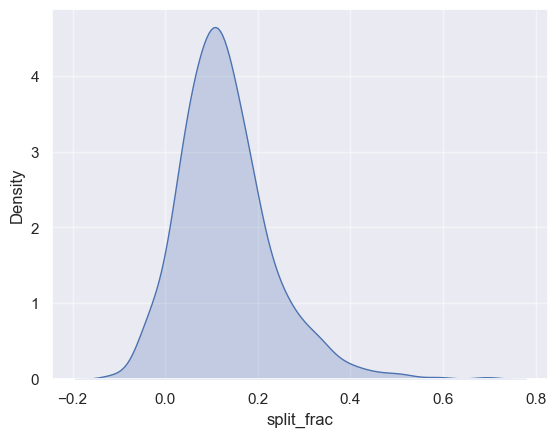

In [50]:
sns.kdeplot(data.split_frac[data.gender=='M'], label='men', fill=True)
sns.kdeplot(data.split_frac[data.gender=='W'], label='women', fill=True)
plt.xlabel('split_frac');

The interesting thing here is that there are many more men than women who are running close to an even split!
It almost looks like a bimodal distribution among the men and women. Let's see if we can suss out what's going on by looking at the distributions as a function of age.

A nice way to compare distributions is to use a *violin plot*, shown in the following figure:

<Axes: xlabel='gender', ylabel='split_frac'>

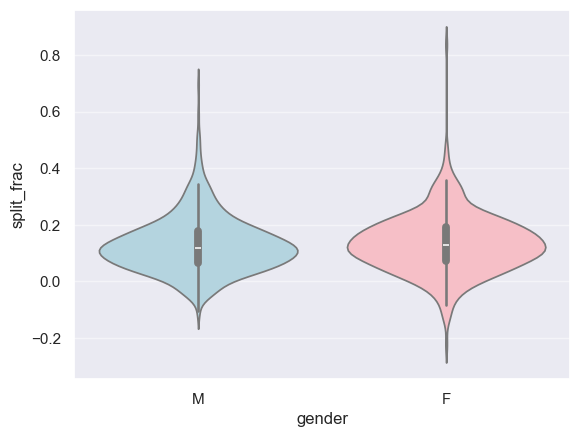

In [52]:
sns.violinplot(x="gender", y="split_frac", data=data,
               hue="gender", palette=["lightblue", "lightpink"],
               legend=False)

Let's look a little deeper, and compare these violin plots as a function of age (see the following figure). We'll start by creating a new column in the array that specifies the age range that each person is in, by decade:

In [53]:
data['age_dec'] = data.age.map(lambda age: 10 * (age // 10))
data.head()

,gender,split,final,split_sec,final_sec,split_frac,age,age_dec
0,M,0 days 01:22:41,0 days 02:47:51,4961.0,10071.0,0.030034,50,50
1,F,0 days 01:39:12,0 days 03:39:28,5952.0,13168.0,0.212366,38,30
2,F,0 days 01:38:26,0 days 03:40:43,5906.0,13243.0,0.242296,57,50
3,M,0 days 02:26:50,0 days 05:04:10,8810.0,18250.0,0.071510,43,40
4,M,0 days 01:51:09,0 days 03:52:36,6669.0,13956.0,0.092668,68,60


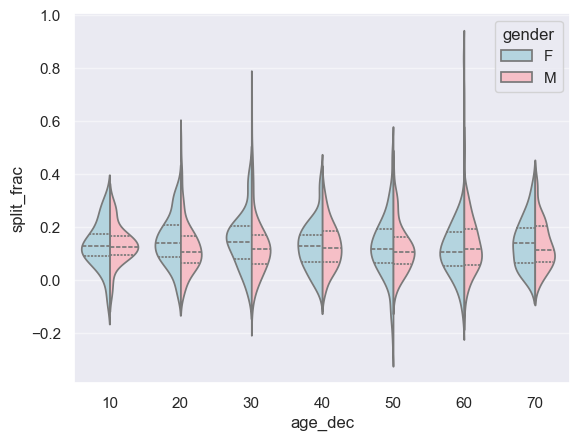

In [57]:
with sns.axes_style(style=None):
    sns.violinplot(x="age_dec", y="split_frac", hue="gender", data=data,
                   split=True, inner="quartile",
                   palette=["lightblue", "lightpink"]);

We can see where the distributions among men and women differ: the split distributions of men in their 20s to 50s show a pronounced overdensity toward lower splits when compared to women of the same age (or of any age, for that matter).

Also surprisingly, it appears that the 80-year-old women seem to outperform *everyone* in terms of their split time, although this is likely a small number effect, as there are only a handful of runners in that range:

In [58]:
(data.age > 80).sum()

np.int64(0)

Back to the men with negative splits: who are these runners? Does this split fraction correlate with finishing quickly? We can plot this very easily. We'll use `regplot`, which will automatically fit a linear regression model to the data (see the following figure):

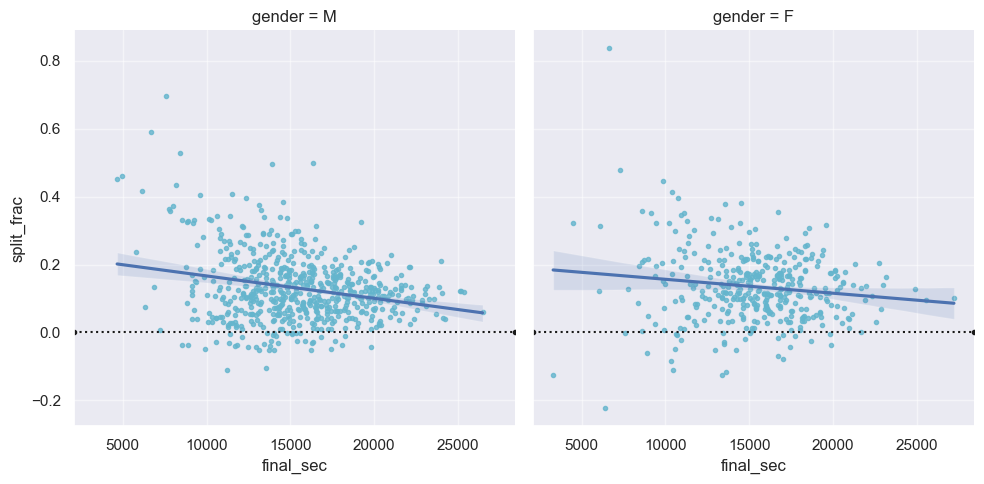

In [59]:
g = sns.lmplot(x='final_sec', y='split_frac', col='gender', data=data,
               markers=".", scatter_kws=dict(color='c'))
g.map(plt.axhline, y=0.0, color="k", ls=":");

| 类别 | 函数 | 作用 |
|------|------|------|
| **分布图** | `histplot` / `kdeplot` / `displot` | 看单变量/双变量分布 |
| **分类图** | `catplot` / `boxplot` / `violinplot` / `barplot` | x 轴是分类变量 |
| **回归图** | `lmplot` / `regplot` | 散点 + 拟合线 |

`lmplot` vs `regplot`：

| 函数 | 特点 |
|------|------|
| `sns.regplot(x, y, data)` | 画**一个**散点+回归线 |
| `sns.lmplot(x, y, data, col='sex')` | `regplot` + `FacetGrid`，支持按列分面 |

Apparently, among both men and women, the people with fast splits tend to be faster runners who are finishing within ~15,000 seconds, or about 4 hours. People slower than that are much less likely to have a fast second split.